# Advanced RAG на реальных данных LegalBPM

Продвинутые техники RAG на реальных документах из базы знаний LegalBPM.

**Что изучим:**
1. **Baseline RAG** — простой vector search (для сравнения)
2. **Multi-Query Retrieval** — генерация нескольких вариантов запроса
3. **HyDE** — Hypothetical Document Embeddings
4. **Reranking** — переранжирование с Cross-Encoder
5. **CRAG** — Corrective RAG с LangGraph

**Стек:** DeepSeek Chat, paraphrase-multilingual-MiniLM-L12-v2, ChromaDB, Cross-Encoder, LangGraph

### Java аналогия:

```java
// Baseline = простой SELECT ... ORDER BY embedding <-> query LIMIT 3
// Multi-Query = UNION нескольких SELECT с разными формулировками
// HyDE = Query by Example (ищем по "примеру ответа", а не по вопросу)
// Reranking = двухфазный поиск (fast recall → precise re-scoring)
// CRAG = @Retryable + quality gate (LangGraph StateGraph)
```

In [ ]:
!pip install -q langchain-text-splitters langgraph chromadb sentence-transformers python-dotenv openai matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup: загрузка реальных данных LegalBPM

Загружаем ~25 ключевых документов (Master Guides + руководства) из приватного репозитория `legalbpm-knowledge-base` через GitHub API.

Документы из разделов: architecture, hibernate-jpa, testing, guides, liquibase.

In [ ]:
%matplotlib inline
from dotenv import load_dotenv
import os, json, base64, subprocess
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb
from openai import OpenAI

load_dotenv("../../.env")

client = OpenAI(
    api_key=os.getenv('DEEPSEEK_API_KEY'),
    base_url='https://api.deepseek.com'
)

embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f'Embedding размерность: {embedding_model.get_sentence_embedding_dimension()}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding размерность: 384


In [ ]:
import shutil, re

# gh CLI: полный путь + очистка ANSI escape codes из stdout
GH_CMD = shutil.which('gh') or r'C:\Program Files\GitHub CLI\gh.exe'
ANSI_RE = re.compile(r'\x1b\[[0-9;]*m')
print(f'gh: {GH_CMD}')

def strip_ansi(text):
    '''Убирает ANSI цветовые коды из вывода gh.'''
    return ANSI_RE.sub('', text)

def list_folder(folder):
    '''Список файлов в папке KB через GitHub API.'''
    result = subprocess.run(
        [GH_CMD, 'api', f'repos/rusliksu/legalbpm-knowledge-base/contents/{folder}'],
        capture_output=True, text=True
    )
    clean = strip_ansi(result.stdout)
    if result.returncode != 0 or not clean.strip():
        print(f'  ⚠️ Ошибка {folder}: {result.stderr[:80]}')
        return []
    return json.loads(clean)

def load_by_sha(sha):
    '''Загрузка файла по SHA (обходит проблемы с пробелами в именах).'''
    result = subprocess.run(
        [GH_CMD, 'api', f'repos/rusliksu/legalbpm-knowledge-base/git/blobs/{sha}'],
        capture_output=True, text=True
    )
    clean = strip_ansi(result.stdout)
    if result.returncode != 0 or not clean.strip():
        raise RuntimeError(f'gh api failed: {result.stderr[:80]}')
    data = json.loads(clean)
    return base64.b64decode(data['content']).decode('utf-8')

# Какие документы загружать (папка → ключевые слова в имени файла)
selection = {
    'architecture': [
        'Master', 'Core Architecture', 'UseCase Patterns',
        'Block Reactions Guide', 'Controller_Architecture',
        'gRPC_Mappers', 'CopyPaste_Templates',
    ],
    'hibernate-jpa': [
        'Master', 'Entity_Lifecycle', 'Performance',
        'Filters_and_Specifications', 'CriteriaQueryHelper',
        'Entity_Structure_Order',
    ],
    'testing': ['Master', 'Mockito'],
    'guides': [
        'Troubleshooting_Guide', 'Code_Review',
        'Top15_Mistakes', 'Git Workflow',
    ],
    'liquibase': ['Master', 'Troubleshooting'],
}

documents = []
for folder, keywords in selection.items():
    print(f'\n📂 {folder}/')
    files = list_folder(folder)
    for f in files:
        name = f.get('name', '')
        if not name.endswith('.md'):
            continue
        if any(kw.lower() in name.lower() for kw in keywords):
            try:
                content = load_by_sha(f['sha'])
                documents.append({
                    'name': name,
                    'folder': folder,
                    'content': content,
                })
                print(f'  ✅ {name[:70]}')
            except Exception as e:
                print(f'  ❌ {name[:50]}: {e}')

print(f'\n📚 Загружено {len(documents)} документов')
for folder in selection:
    count = sum(1 for d in documents if d['folder'] == folder)
    print(f'   {folder}: {count}')

gh: C:\Program Files\GitHub CLI\gh.EXE

📂 architecture/


  ✅ LegalBPM Block Reactions Guide (Updated) - Полный гайд по блокам.md


  ✅ LegalBPM Core Architecture (Updated July 14, 2025).md


  ✅ LegalBPM GetAll UseCase Patterns & Architecture Guide (Updated July 7,


  ✅ LegalBPM UseCase Patterns & Stream API Best Practices (Updated July 16


...

  ✅ LegalBPM_Code_Review_-_Master_Guide.md


  ✅ LegalBPM_Top15_Mistakes__03_01_26_.md


  ✅ LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26_.md

📂 liquibase/


  ✅ LegalBPM_Liquibase_Best_Practices_-_Master_Guide.md


  ✅ LegalBPM_Liquibase_Troubleshooting_-_Master_Guide.md

📚 Загружено 27 документов
   architecture: 13
   hibernate-jpa: 6
   testing: 2
   guides: 4
   liquibase: 2


### Markdown-aware Chunking

Разбиваем документы на фрагменты, учитывая структуру Markdown.

Приоритет разделителей: `## Заголовок` → `### Подзаголовок` → абзац → предложение.

### Java аналогия:

```java
// Chunking — это как пагинация, но по смыслу
// Обычная пагинация: Pageable.ofSize(100) — жёстко по количеству
// Chunking: разбивает по логическим границам (заголовки, абзацы)
// Аналог: BufferedReader с умным разделением по маркерам
```

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=['\n## ', '\n### ', '\n#### ', '\n\n', '\n', '. ', ' ']
)

chunks = []
for doc in documents:
    doc_chunks = splitter.split_text(doc['content'])
    for i, chunk_text in enumerate(doc_chunks):
        chunks.append({
            'id': f"{doc['folder']}_{doc['name'][:40]}_{i}",
            'text': chunk_text,
            'folder': doc['folder'],
            'filename': doc['name'],
        })

print(f'📄 {len(documents)} документов → {len(chunks)} chunks')
print(f'   Средний размер chunk: {np.mean([len(c["text"]) for c in chunks]):.0f} символов')

# Индексация в ChromaDB
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(
    name='legalbpm_advanced_rag',
    metadata={'hnsw:space': 'cosine'}
)

batch_size = 100
for i in range(0, len(chunks), batch_size):
    batch = chunks[i:i+batch_size]
    texts = [c['text'] for c in batch]
    embs = embedding_model.encode(texts).tolist()
    collection.add(
        ids=[c['id'] for c in batch],
        documents=texts,
        embeddings=embs,
        metadatas=[{'folder': c['folder'], 'filename': c['filename']} for c in batch],
    )
    print(f'  Indexed {min(i+batch_size, len(chunks))}/{len(chunks)}')

print(f'\n✅ ChromaDB: {collection.count()} chunks')

📄 27 документов → 847 chunks
   Средний размер chunk: 641 символов


  Indexed 100/847


  Indexed 200/847


  Indexed 300/847


  Indexed 400/847


  Indexed 500/847


  Indexed 600/847


  Indexed 700/847


  Indexed 800/847


  Indexed 847/847

✅ ChromaDB: 847 chunks


## 2. Baseline RAG

Простейший RAG: vector search → top-3 документа → LLM.

Это наша **базовая линия** — все техники дальше будем сравнивать с ней.

In [ ]:
def vector_search(query, n_results=3):
    '''Поиск ближайших chunks по cosine similarity.'''
    query_emb = embedding_model.encode(query).tolist()
    return collection.query(query_embeddings=[query_emb], n_results=n_results)

def llm_generate(question, context, system_prompt=None):
    '''Генерация ответа через DeepSeek.'''
    if system_prompt is None:
        system_prompt = (
            'Ты эксперт по проекту LegalBPM (Java, Spring Boot). '
            'Отвечай ТОЛЬКО на основе предоставленного контекста. '
            'Если информации нет — честно скажи. Кратко и по делу, на русском.'
        )
    response = client.chat.completions.create(
        model='deepseek-chat',
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': f'Контекст:\n{context}\n\nВопрос: {question}'},
        ],
        max_tokens=500,
        temperature=0.3,
    )
    return response.choices[0].message.content

def baseline_rag(question, n_results=3):
    '''Baseline RAG: vector search → LLM.'''
    results = vector_search(question, n_results)
    docs = results['documents'][0]
    sources = [m['filename'] for m in results['metadatas'][0]]
    context = '\n\n---\n\n'.join(docs)
    answer = llm_generate(question, context)
    return {'answer': answer, 'docs': docs, 'sources': sources}

print('✅ Baseline RAG готов')

✅ Baseline RAG готов


In [ ]:
test_questions = [
    'Как работают реакции в LegalBPM?',
    'Как тестировать UseCase с Mockito?',
    'Какие проблемы с N+1 запросами в Hibernate?',
    'Как правильно делать code review?',
    'Что делать при ошибке Liquibase миграции?',
]

print('=' * 70)
print('BASELINE RAG')
print('=' * 70)

baseline_results = {}
for q in test_questions:
    result = baseline_rag(q)
    baseline_results[q] = result
    print(f'\n❓ {q}')
    print(f'📎 Источники: {", ".join(result["sources"][:2])}')
    print(f'💬 {result["answer"][:200]}...')
    print('-' * 50)

BASELINE RAG



❓ Как работают реакции в LegalBPM?
📎 Источники: LegalBPM Block Reactions Guide (Updated) - Полный гайд по блокам.md, LegalBPM_Reactions_-_Master_Guide.md
💬 На основе предоставленного контекста, вот как работают реакции в LegalBPM:

### Основные принципы работы реакций:
1. **Реакции создаются/обновляются** в ответ на действия пользователя с блоками в сист...
--------------------------------------------------



❓ Как тестировать UseCase с Mockito?
📎 Источники: LegalBPM_Mockito_and_Test_Utilities.md, LegalBPM_Testing_Master_Guide.md
💬 На основе предоставленного контекста:

**Для тестирования UseCase с Mockito в LegalBPM:**

1. **Аннотации:**
   - Используй `@ExtendWith(MockitoExtension.class)` для JUnit 5
   - Для сложных UseCase п...
--------------------------------------------------



❓ Какие проблемы с N+1 запросами в Hibernate?
📎 Источники: LegalBPM_Set_vs_List_Collections_-_Master_Guide.md, Hibernate_JPA_Performance_and_Queries_-_Master_Guide.md
💬 На основе предоставленного контекста:

**Проблемы с N+1 запросами в Hibernate, упомянутые в контексте:**

1. **EntityGraph ломается при несовпадении типов коллекций** - если в entity используется `Set...
--------------------------------------------------



❓ Как правильно делать code review?
📎 Источники: LegalBPM_Code_Review_-_Master_Guide.md, LegalBPM UseCase Patterns & Stream API Best Practices (Updated July 16, 2025).md
💬 На основе контекста, правильный code review зависит от типа задачи, опыта разработчика и критичности изменений.

**Процесс состоит из двух этапов:**

1.  **Self-Review (обязательный перед созданием PR...
--------------------------------------------------



❓ Что делать при ошибке Liquibase миграции?
📎 Источники: LegalBPM_Liquibase_Best_Practices_-_Master_Guide.md, LegalBPM_Development_Patterns_-_Master_Guide.md
💬 На основе предоставленного контекста информация о действиях при ошибке Liquibase миграции отсутствует. Контекст содержит только пример структуры changeSet с preConditions и rollback, но не описывает п...
--------------------------------------------------


### Проблемы Baseline RAG

1. **Vocabulary mismatch** — запрос «как работают реакции» может не найти chunk с `ObjectTypeReactionMapping`
2. **Односторонний поиск** — один запрос = одна точка в embedding пространстве
3. **Нет проверки качества** — если найденные документы нерелевантны, LLM всё равно генерирует ответ

Следующие техники решают эти проблемы:
- **Multi-Query** → проблемы 1, 2
- **HyDE** → проблема 1
- **Reranking** → проблема 2
- **CRAG** → проблема 3

## 3. Multi-Query Retrieval

**Идея:** один вопрос → LLM генерирует 3 разных формулировки → поиск по каждой → объединение результатов.

```
Вопрос: "Как работают реакции?"
    ↓ LLM генерирует варианты
├─ "CourtReaction паттерн реализация"
├─ "ObjectTypeReactionMapping аннотация"
└─ "Реакции на события блоков LegalBPM"
    ↓ Поиск по каждому
    ↓ Объединение уникальных результатов
    ↓ LLM → Ответ
```

### Java аналогия:

```java
// Multi-Query — это как Specification с OR
Specification<Doc> spec1 = byText("реакции");
Specification<Doc> spec2 = byText("CourtReaction");
Specification<Doc> spec3 = byText("ObjectTypeReactionMapping");

List<Doc> results = repo.findAll(spec1.or(spec2).or(spec3));
// Больше покрытие → меньше пропусков
```

In [ ]:
def generate_search_queries(question, n=3):
    '''LLM генерирует n вариантов поискового запроса.'''
    response = client.chat.completions.create(
        model='deepseek-chat',
        messages=[
            {'role': 'system', 'content': (
                f'Сгенерируй {n} разных формулировок для поиска по технической '
                'документации Java/Spring Boot проекта. '
                'Каждая формулировка должна покрывать разные аспекты вопроса. '
                'Верни ТОЛЬКО JSON массив строк, без markdown.'
            )},
            {'role': 'user', 'content': question},
        ],
        temperature=0.7,
        max_tokens=300,
    )
    text = response.choices[0].message.content.strip()
    # Очистка от markdown обёрток
    if text.startswith('```'):
        text = text.split('\n', 1)[1].rsplit('```', 1)[0]
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return [line.strip().strip('"') for line in text.split('\n') if line.strip()]

def multi_query_rag(question, n_queries=3, n_per_query=3):
    '''Multi-Query RAG: несколько запросов → объединение результатов.'''
    queries = generate_search_queries(question, n_queries)

    seen_ids = set()
    all_docs = []
    all_sources = []

    for q in queries:
        results = vector_search(q, n_per_query)
        for doc_id, text, meta in zip(
            results['ids'][0], results['documents'][0], results['metadatas'][0]
        ):
            if doc_id not in seen_ids:
                seen_ids.add(doc_id)
                all_docs.append(text)
                all_sources.append(meta['filename'])

    # Берём top-5 уникальных результатов
    context = '\n\n---\n\n'.join(all_docs[:5])
    answer = llm_generate(question, context)

    return {
        'answer': answer,
        'queries': queries,
        'docs': all_docs[:5],
        'sources': all_sources[:5],
    }

print('✅ Multi-Query RAG готов')

✅ Multi-Query RAG готов


In [ ]:
print('=' * 70)
print('MULTI-QUERY RAG')
print('=' * 70)

mq_results = {}
for q in test_questions:
    result = multi_query_rag(q)
    mq_results[q] = result
    print(f'\n❓ {q}')
    print(f'🔀 Сгенерированные запросы:')
    for i, sq in enumerate(result['queries'], 1):
        print(f'   {i}. {sq}')
    print(f'📎 Источники ({len(result["sources"])}): {", ".join(result["sources"][:3])}')
    print(f'💬 {result["answer"][:200]}...')
    print('-' * 50)

MULTI-QUERY RAG



❓ Как работают реакции в LegalBPM?
🔀 Сгенерированные запросы:
   1. Как реализованы реакции (reactions) в LegalBPM: архитектура, компоненты и взаимодействие
   2. Описание механизма реакций в LegalBPM: настройка, триггеры и обработка событий
   3. Техническая реализация реакций в LegalBPM: используемые технологии, API и примеры кода
📎 Источники (4): LegalBPM Block Reactions Guide (Updated) - Полный гайд по блокам.md, LegalBPM_Reactions_-_Master_Guide.md, LegalBPM_TagsRecalculate_Reactions_-_Master_Guide.md
💬 На основе предоставленного контекста, вот как работают реакции в LegalBPM:

**Основная концепция:** Реакции — это автоматические обработчики, которые выполняются при создании или обновлении объектов в...
--------------------------------------------------



❓ Как тестировать UseCase с Mockito?
🔀 Сгенерированные запросы:
   1. Как написать unit-тест для UseCase с использованием Mockito в Spring Boot приложении?
   2. Какие аннотации Mockito и подходы использовать для тестирования UseCase с зависимостями?
   3. Как настроить моки репозиториев и сервисов при тестировании UseCase с помощью Mockito?
📎 Источники (5): LegalBPM_Testing_Master_Guide.md, LegalBPM_Top15_Mistakes__03_01_26_.md, LegalBPM_Testing_Master_Guide.md
💬 На основе контекста, вот ключевые правила тестирования UseCase с Mockito в LegalBPM:

### 1. **Выбор типа теста**
*   **Для `lib-*` модулей (чистая бизнес-логика):** используйте **Unit-тесты** с `@Ext...
--------------------------------------------------



❓ Какие проблемы с N+1 запросами в Hibernate?
🔀 Сгенерированные запросы:
   1. Как избежать проблемы N+1 запросов при использовании Hibernate в Spring Boot приложении?
   2. Какие стратегии оптимизации производительности доступны в Hibernate для решения проблемы N+1 запросов?
   3. Как настроить eager loading или batch fetching в Hibernate, чтобы предотвратить проблему N+1 запросов?
📎 Источники (5): LegalBPM_Set_vs_List_Collections_-_Master_Guide.md, Hibernate_JPA_Entity_Lifecycle_and_Persistence_-_Master_Guide.md, LegalBPM_Testing_Master_Guide.md
💬 На основе предоставленного контекста:

**Проблема N+1 в Hibernate** возникает при загрузке списка сущностей с lazy-коллекциями:
1. **1 запрос** для загрузки основного списка сущностей
2. **N запросов*...
--------------------------------------------------



❓ Как правильно делать code review?
🔀 Сгенерированные запросы:
   1. Как проводить code review в Java/Spring Boot проектах: лучшие практики и критерии оценки кода
   2. Процесс code review в Spring Boot приложениях: проверка архитектуры, тестирования и безопасности
   3. Инструменты и методологии code review для Java проектов: checklist, автоматизация и командное взаимодействие
📎 Источники (5): LegalBPM_Dictionary_-_Master_Guide.md, LegalBPM_Testing_Master_Guide.md, LegalBPM_Code_Review_-_Master_Guide.md
💬 На основе предоставленного контекста:

**Детальный code review (ДА) нужен когда:**
1. **Новая интеграция** (любой опыт разработчика, высокая критичность)
2. **Новый компонент** (lib, router) - любой о...
--------------------------------------------------



❓ Что делать при ошибке Liquibase миграции?
🔀 Сгенерированные запросы:
   1. Как исправить ошибку выполнения миграции Liquibase в Spring Boot приложении
   2. Процедура отката и восстановления после сбоя миграции базы данных Liquibase
   3. Диагностика и решение проблем с changelog и скриптами миграций Liquibase
📎 Источники (5): LegalBPM_Liquibase_Troubleshooting_-_Master_Guide.md, LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26_.md, LegalBPM_Development_Patterns_-_Master_Guide.md
💬 На основе предоставленного контекста:

При ошибке Liquibase миграции:
1. **Проверить логи приложения** с помощью команды `grep "Liquibase" application.log` для поиска конкретных ошибок
2. **Rollback в...
--------------------------------------------------


## 4. HyDE (Hypothetical Document Embeddings)

**Идея:** вместо поиска по вопросу, LLM генерирует **гипотетический ответ** → embedding этого ответа → поиск.

Почему это работает? Embedding «ответа» ближе к embeddings реальных документов, чем embedding «вопроса».

```
Вопрос: "Как работают реакции?"
    ↓ LLM генерирует гипотетический ответ
"Реакции в LegalBPM — это обработчики событий, привязанные
к типам объектов через @ObjectTypeReactionMapping..."
    ↓ Embedding этого текста
    ↓ Vector search (embedding ответа ≈ embedding реальных docs)
    ↓ Реальные документы → LLM → Финальный ответ
```

### Java аналогия:

```java
// HyDE — это как поиск по примеру (Query by Example)
// Вместо критериев, даёшь пример того что ищешь

// Spring Data JPA:
Example<Employee> example = Example.of(new Employee("developer"));
List<Employee> found = repo.findAll(example);

// HyDE:
String hypothetical = llm.generate("как бы выглядел ответ?");
float[] hyp_embedding = embed(hypothetical);
List<Doc> found = vectorDb.search(hyp_embedding);
```

In [ ]:
def generate_hypothetical_doc(question):
    '''LLM генерирует гипотетический параграф документации.'''
    response = client.chat.completions.create(
        model='deepseek-chat',
        messages=[
            {'role': 'system', 'content': (
                'Ты технический писатель проекта LegalBPM (Java, Spring Boot, Hibernate). '
                'Напиши параграф из технической документации, который бы отвечал на вопрос. '
                'Пиши как настоящую документацию с конкретными деталями '
                '(имена классов, аннотации, паттерны). Не говори что это гипотеза.'
            )},
            {'role': 'user', 'content': question},
        ],
        temperature=0.7,
        max_tokens=300,
    )
    return response.choices[0].message.content

def hyde_rag(question, n_results=3):
    '''HyDE RAG: гипотетический ответ → embedding → search → answer.'''
    # 1. Генерация гипотетического документа
    hypothetical = generate_hypothetical_doc(question)

    # 2. Embedding гипотезы
    hyp_emb = embedding_model.encode(hypothetical).tolist()

    # 3. Поиск реальных документов по embedding гипотезы
    results = collection.query(query_embeddings=[hyp_emb], n_results=n_results)

    # 4. Генерация ответа из реальных документов
    docs = results['documents'][0]
    sources = [m['filename'] for m in results['metadatas'][0]]
    context = '\n\n---\n\n'.join(docs)
    answer = llm_generate(question, context)

    return {
        'answer': answer,
        'hypothetical': hypothetical,
        'docs': docs,
        'sources': sources,
    }

print('✅ HyDE RAG готов')

✅ HyDE RAG готов


In [ ]:
print('=' * 70)
print('HyDE RAG')
print('=' * 70)

hyde_results = {}
for q in test_questions:
    result = hyde_rag(q)
    hyde_results[q] = result
    print(f'\n❓ {q}')
    print(f'📝 Гипотетический документ:')
    print(f'   {result["hypothetical"][:150]}...')
    print(f'📎 Реальные источники: {", ".join(result["sources"][:3])}')
    print(f'💬 {result["answer"][:200]}...')
    print('-' * 50)

HyDE RAG



❓ Как работают реакции в LegalBPM?
📝 Гипотетический документ:
   ## Реакции в LegalBPM: механизм обработки событий процесса

В LegalBPM реакции реализованы через систему **Event-Driven Reaction Engine**, построенную...
📎 Реальные источники: LegalBPM_Reactions_-_Master_Guide.md, LegalBPM_Reactions_-_Master_Guide.md, LegalBPM_Testing_Master_Guide.md
💬 На основе предоставленного контекста:

Реакции в LegalBPM — это компоненты, реализующие интерфейс `CourtReaction`, которые выполняют бизнес-логику в ответ на события. Каждая реакция регистрируется анн...
--------------------------------------------------



❓ Как тестировать UseCase с Mockito?
📝 Гипотетический документ:
   Для тестирования UseCase с использованием Mockito в проекте LegalBPM применяется подход изоляции бизнес-логики от зависимостей через моки. Каждый UseC...
📎 Реальные источники: LegalBPM_Testing_Master_Guide.md, LegalBPM GetAll UseCase Patterns & Architecture Guide (Updated July 7, 2025).md.md, LegalBPM_Controller_Architecture_Guidelines__Обновлено_07_11_25_.md
💬 На основе контекста, UseCase тестируются с фокусом на бизнес-логике, используя Mockito для изоляции слоя. Вот ключевые принципы:

## Структура теста UseCase:
```java
@ExtendWith(MockitoExtension.class...
--------------------------------------------------



❓ Какие проблемы с N+1 запросами в Hibernate?
📝 Гипотетический документ:
   В проекте LegalBPM проблема N+1 запросов возникает при использовании ленивой загрузки (LAZY) связанных сущностей без применения стратегий оптимизации....
📎 Реальные источники: Hibernate_JPA_Performance_and_Queries_-_Master_Guide.md, LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26_.md, LegalBPM_CriteriaQueryHelper_-_Master_Guide.md
💬 На основе контекста, проблемы с N+1 запросами в Hibernate включают:

**Симптомы:**
- Медленные запросы
- Множественные SELECT в логах Hibernate
- Ошибки при использовании JOIN FETCH

**Диагностика:**
...
--------------------------------------------------



❓ Как правильно делать code review?
📝 Гипотетический документ:
   ## Процедура проведения Code Review в проекте LegalBPM

Code review в проекте LegalBPM осуществляется через систему контроля версий Git с использовани...
📎 Реальные источники: LegalBPM Git Workflow Guide.md, LegalBPM Git Workflow Guide.md, LegalBPM_Code_Review_-_Master_Guide.md
💬 На основе предоставленного контекста, информация о процессе code review в LegalBPM содержится в объединенных документах, перечисленных в разделе "Sources" (например, `LegalBPM Code Review Rules & Arch...
--------------------------------------------------



❓ Что делать при ошибке Liquibase миграции?
📝 Гипотетический документ:
   ## Обработка ошибок миграции Liquibase

При возникновении ошибки во время выполнения миграции Liquibase в LegalBPM, система автоматически переводит тр...
📎 Реальные источники: LegalBPM_Liquibase_Best_Practices_-_Master_Guide.md, LegalBPM_Development_Patterns_-_Master_Guide.md, LegalBPM_Liquibase_Troubleshooting_-_Master_Guide.md
💬 На основе контекста, прямого ответа на вопрос "Что делать при ошибке Liquibase миграции?" нет. В предоставленной информации описаны только механизм работы, структура changeset'а и логи успешного приме...
--------------------------------------------------


## 5. Reranking с Cross-Encoder

**Идея:** vector search находит top-10 кандидатов → Cross-Encoder переранжирует → берём top-3.

**Зачем?** Bi-encoder (embedding модель) быстрый, но неточный — кодирует вопрос и документ **отдельно**.
Cross-encoder медленный, но точнее — видит вопрос и документ **одновременно**.

```
Запрос → Vector Search (top-10, быстро)
              ↓
         Cross-Encoder (попарно: запрос + doc₁, запрос + doc₂, ...)
              ↓
         Переранжированный top-3 (точно)
              ↓
         LLM → Ответ
```

### Java аналогия:

```java
// Reranking — это двухэтапная фильтрация
// Этап 1: грубый поиск (как индекс в БД)
List<Doc> candidates = vectorDb.search(query, limit=10);

// Этап 2: точная сортировка (как full scan с функцией)
candidates.sort(Comparator.comparing(
    doc -> crossEncoder.score(query, doc.getText())
).reversed());

List<Doc> topDocs = candidates.subList(0, 3);

// Аналог в Elasticsearch:
// query → BM25 (fast recall) → rescorer (precise ranking)
```

In [ ]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print('✅ Cross-Encoder загружен')

def rerank_rag(question, initial_k=10, final_k=3):
    '''Reranking RAG: vector search (top-K) → cross-encoder → top-N.'''
    # 1. Широкий vector search
    results = vector_search(question, initial_k)
    docs = results['documents'][0]
    metas = results['metadatas'][0]

    # 2. Cross-encoder scoring
    pairs = [[question, doc] for doc in docs]
    scores = cross_encoder.predict(pairs)

    # 3. Сортировка по score
    ranked = sorted(
        zip(docs, metas, scores),
        key=lambda x: x[2],
        reverse=True,
    )

    top_docs = [doc for doc, meta, score in ranked[:final_k]]
    top_sources = [meta['filename'] for doc, meta, score in ranked[:final_k]]
    top_scores = [float(score) for doc, meta, score in ranked[:final_k]]

    # 4. Генерация
    context = '\n\n---\n\n'.join(top_docs)
    answer = llm_generate(question, context)

    return {
        'answer': answer,
        'docs': top_docs,
        'sources': top_sources,
        'scores': top_scores,
    }

print('✅ Reranking RAG готов')

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ruslan\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Cross-Encoder загружен
✅ Reranking RAG готов


In [ ]:
print('=' * 70)
print('RERANKING RAG')
print('=' * 70)

rerank_results = {}
for q in test_questions:
    result = rerank_rag(q)
    rerank_results[q] = result
    print(f'\n❓ {q}')
    print(f'📊 Cross-Encoder scores:')
    for src, score in zip(result['sources'], result['scores']):
        print(f'   {score:.4f}  {src[:60]}')
    print(f'💬 {result["answer"][:200]}...')
    print('-' * 50)

RERANKING RAG



❓ Как работают реакции в LegalBPM?
📊 Cross-Encoder scores:
   7.8350  LegalBPM Block Reactions Guide (Updated) - Полный гайд по бл
   7.3762  LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26_.md
   7.2963  LegalBPM_Entity_Structure_Order_Guide__21_11_25_.md
💬 На основе предоставленного контекста, в документе "LegalBPM Block Reactions Guide (Updated)" содержится полный гайд по работе с пользовательскими блоками, который **включает реакции создания/обновлени...
--------------------------------------------------



❓ Как тестировать UseCase с Mockito?
📊 Cross-Encoder scores:
   7.8432  LegalBPM_Testing_Master_Guide.md
   7.5116  LegalBPM_Testing_Master_Guide.md
   6.3426  LegalBPM_Testing_Master_Guide.md
💬 На основе контекста, тестирование UseCase с Mockito должно следовать этим принципам:

**1. Базовая структура теста:**
```java
@ExtendWith(MockitoExtension.class)
class UpdateUsersUISettingsUseCaseImpl...
--------------------------------------------------



❓ Какие проблемы с N+1 запросами в Hibernate?
📊 Cross-Encoder scores:
   7.9544  Hibernate_JPA_Performance_and_Queries_-_Master_Guide.md
   7.2463  Hibernate_JPA_Entity_Lifecycle_and_Persistence_-_Master_Guid
   6.8989  Hibernate_JPA_Performance_and_Queries_-_Master_Guide.md
💬 На основе предоставленного контекста:

**Проблемы с N+1 запросами в Hibernate:**

1. **Производительность:** Основная проблема — резкое падение производительности. При загрузке списка сущностей с лени...
--------------------------------------------------



❓ Как правильно делать code review?
📊 Cross-Encoder scores:
   8.3280  LegalBPM_Code_Review_-_Master_Guide.md
   8.1065  LegalBPM_Code_Review_-_Master_Guide.md
   7.9109  LegalBPM_Code_Review_-_Master_Guide.md
💬 На основе контекста, правильный code review делается с использованием обучающих техник и с учетом типа задачи.

**Обучающие техники:**
1.  **Используй "Сократовские вопросы"**: вместо прямых указаний ...
--------------------------------------------------



❓ Что делать при ошибке Liquibase миграции?
📊 Cross-Encoder scores:
   8.3734  LegalBPM_Liquibase_Best_Practices_-_Master_Guide.md
   7.5124  LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26_.md
   7.3887  LegalBPM Core Architecture (Updated July 14, 2025).md
💬 На основе предоставленного контекста:

При ошибке Liquibase миграции можно выполнить **явный откат (rollback)**, так как все changeset'ы написаны с rollback-секцией. 

Для этого используется команда:
...
--------------------------------------------------


## 6. CRAG (Corrective RAG) с LangGraph

**Идея:** после поиска, LLM **оценивает** каждый найденный документ. Если они нерелевантны — переформулирует запрос и ищет заново.

Это **self-correcting** RAG — система сама определяет качество поиска.

```
┌──────────┐     ┌──────────┐     ┌───────────────┐
│ Retrieve │────▶│  Grade   │────▶│  Relevant?    │
└──────────┘     │Documents │     │               │
                 └──────────┘     │ YES → Generate │
                                  │ NO  → Rewrite  │
                                  └───────┬────────┘
                                          │
                                  ┌───────▼────────┐
                                  │ Rewrite Query  │──── loop back
                                  └────────────────┘
```

### Java аналогия:

```java
// CRAG — это Retry Pattern + Quality Gate
@Retryable(maxAttempts = 3)
String answerWithRetry(String question) {
    List<Doc> docs = search(question);

    // Quality gate
    if (!gradeRelevance(docs, question)) {
        question = rewriteQuery(question);
        throw new RetryableException("Документы нерелевантны");
    }

    return generate(docs, question);
}

// Или через Spring State Machine / LangGraph:
// State: RETRIEVE → GRADE → [GENERATE | REWRITE → RETRIEVE]
```

Связь с пройденным: это **StateGraph** из LangGraph — `conditional_edges`, циклы, состояние.

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

class CRAGState(TypedDict):
    question: str
    original_question: str
    documents: List[str]
    sources: List[str]
    generation: str
    retries: int
    grading_log: List[str]

def retrieve_node(state: CRAGState) -> dict:
    '''Retrieve: поиск документов.'''
    results = vector_search(state['question'], n_results=5)
    return {
        'documents': results['documents'][0],
        'sources': [m['filename'] for m in results['metadatas'][0]],
    }

def grade_node(state: CRAGState) -> dict:
    '''Grade: LLM оценивает релевантность каждого документа.'''
    relevant_docs = []
    relevant_sources = []
    log = []

    for doc, source in zip(state['documents'], state['sources']):
        response = client.chat.completions.create(
            model='deepseek-chat',
            messages=[
                {'role': 'system', 'content': (
                    'Определи, содержит ли документ информацию для ответа на вопрос. '
                    "Ответь ТОЛЬКО одним словом: 'yes' или 'no'."
                )},
                {'role': 'user', 'content': (
                    f'Вопрос: {state["question"]}\n\nДокумент:\n{doc[:500]}'
                )},
            ],
            max_tokens=5,
            temperature=0,
        )
        grade = response.choices[0].message.content.strip().lower()
        is_relevant = 'yes' in grade
        symbol = '✅' if is_relevant else '❌'
        log.append(f'{symbol} {source[:50]}')

        if is_relevant:
            relevant_docs.append(doc)
            relevant_sources.append(source)

    return {
        'documents': relevant_docs,
        'sources': relevant_sources,
        'grading_log': state.get('grading_log', []) + log,
    }

def should_generate(state: CRAGState) -> str:
    '''Решение: генерировать или переформулировать?'''
    if len(state['documents']) > 0:
        return 'generate'
    if state.get('retries', 0) >= 2:
        return 'generate'  # После 2 попыток генерируем в любом случае
    return 'rewrite'

def rewrite_node(state: CRAGState) -> dict:
    '''Rewrite: переформулировка запроса.'''
    response = client.chat.completions.create(
        model='deepseek-chat',
        messages=[
            {'role': 'system', 'content': (
                'Переформулируй вопрос для лучшего поиска по технической документации. '
                'Используй другие термины, синонимы, более конкретные слова. '
                'Верни ТОЛЬКО переформулированный вопрос.'
            )},
            {'role': 'user', 'content': (
                f'Исходный вопрос: {state["original_question"]}\n'
                f'Текущий запрос: {state["question"]}'
            )},
        ],
        max_tokens=100,
        temperature=0.7,
    )
    new_q = response.choices[0].message.content.strip()
    return {
        'question': new_q,
        'retries': state.get('retries', 0) + 1,
        'grading_log': state.get('grading_log', []) + [f'🔄 Rewrite: {new_q}'],
    }

def generate_node(state: CRAGState) -> dict:
    '''Generate: финальный ответ.'''
    if state['documents']:
        context = '\n\n---\n\n'.join(state['documents'])
    else:
        context = 'Релевантные документы не найдены.'
    answer = llm_generate(state['original_question'], context)
    return {'generation': answer}

# Строим граф
workflow = StateGraph(CRAGState)
workflow.add_node('retrieve', retrieve_node)
workflow.add_node('grade', grade_node)
workflow.add_node('rewrite', rewrite_node)
workflow.add_node('generate', generate_node)

workflow.set_entry_point('retrieve')
workflow.add_edge('retrieve', 'grade')
workflow.add_conditional_edges('grade', should_generate, {
    'generate': 'generate',
    'rewrite': 'rewrite',
})
workflow.add_edge('rewrite', 'retrieve')
workflow.add_edge('generate', END)

crag_app = workflow.compile()
print('✅ CRAG граф скомпилирован')

def crag_rag(question):
    '''Запуск CRAG.'''
    result = crag_app.invoke({
        'question': question,
        'original_question': question,
        'documents': [],
        'sources': [],
        'generation': '',
        'retries': 0,
        'grading_log': [],
    })
    return {
        'answer': result['generation'],
        'sources': result['sources'],
        'retries': result['retries'],
        'log': result['grading_log'],
    }

✅ CRAG граф скомпилирован


In [ ]:
print('=' * 70)
print('CRAG (Corrective RAG)')
print('=' * 70)

crag_results = {}
for q in test_questions:
    result = crag_rag(q)
    crag_results[q] = result
    print(f'\n❓ {q}')
    print(f'🔄 Попыток: {result["retries"] + 1}')
    print(f'📋 Лог grading:')
    for entry in result['log']:
        print(f'   {entry[:80]}')
    print(f'📎 Источники: {", ".join(result["sources"][:3])}')
    print(f'💬 {result["answer"][:200]}...')
    print('-' * 50)

CRAG (Corrective RAG)



❓ Как работают реакции в LegalBPM?
🔄 Попыток: 1
📋 Лог grading:
   ❌ LegalBPM Block Reactions Guide (Updated) - Полный 
   ✅ LegalBPM_Reactions_-_Master_Guide.md
   ❌ LegalBPM_Testing_Master_Guide.md
   ❌ LegalBPM_TagsRecalculate_Reactions_-_Master_Guide.
   ❌ LegalBPM_Liquibase_Best_Practices_-_Master_Guide.m
📎 Источники: LegalBPM_Reactions_-_Master_Guide.md
💬 На основе предоставленного контекста, реакции в LegalBPM — это механизм автоматического выполнения кода в ответ на события в системе. Вот ключевые принципы их работы:

### 1. **Триггеры (События)**
Ре...
--------------------------------------------------



❓ Как тестировать UseCase с Mockito?
🔄 Попыток: 1
📋 Лог grading:
   ✅ LegalBPM_Mockito_and_Test_Utilities.md
   ✅ LegalBPM_Testing_Master_Guide.md
   ✅ LegalBPM_Testing_Master_Guide.md
   ✅ LegalBPM_Mockito_and_Test_Utilities.md
   ✅ LegalBPM_Filters_and_Specifications_-_Master_Guide
📎 Источники: LegalBPM_Mockito_and_Test_Utilities.md, LegalBPM_Testing_Master_Guide.md, LegalBPM_Testing_Master_Guide.md
💬 На основе предоставленного контекста по LegalBPM:

**Как тестировать UseCase с Mockito:**

1. **Аннотации и структура:**
   - Используй `@ExtendWith(MockitoExtension.class)` для JUnit 5
   - `@Mock` д...
--------------------------------------------------



❓ Какие проблемы с N+1 запросами в Hibernate?
🔄 Попыток: 1
📋 Лог grading:
   ✅ LegalBPM_Set_vs_List_Collections_-_Master_Guide.md
   ❌ Hibernate_JPA_Performance_and_Queries_-_Master_Gui
   ❌ Hibernate_JPA_Entity_Lifecycle_and_Persistence_-_M
   ❌ Hibernate_JPA_Entity_Lifecycle_and_Persistence_-_M
   ✅ Hibernate_JPA_Performance_and_Queries_-_Master_Gui
📎 Источники: LegalBPM_Set_vs_List_Collections_-_Master_Guide.md, Hibernate_JPA_Performance_and_Queries_-_Master_Guide.md
💬 На основе предоставленного контекста:

**Проблема N+1 в Hibernate** возникает при загрузке списка сущностей с ленивыми (lazy) коллекциями:
1. Выполняется **1 запрос** для загрузки основного списка сущ...
--------------------------------------------------



❓ Как правильно делать code review?
🔄 Попыток: 1
📋 Лог grading:
   ❌ LegalBPM_Code_Review_-_Master_Guide.md
   ✅ LegalBPM UseCase Patterns & Stream API Best Practi
   ✅ LegalBPM_Code_Review_-_Master_Guide.md
   ✅ LegalBPM_Code_Review_-_Master_Guide.md
   ❌ LegalBPM_Code_Review_-_Master_Guide.md
📎 Источники: LegalBPM UseCase Patterns & Stream API Best Practices (Updated July 16, 2025).md, LegalBPM_Code_Review_-_Master_Guide.md, LegalBPM_Code_Review_-_Master_Guide.md
💬 На основе предоставленного контекста, правильный code review в LegalBPM должен следовать структурированному подходу, описанному в мастер-документе. Вот ключевые шаги:

### 1. **Самостоятельная проверк...
--------------------------------------------------



❓ Что делать при ошибке Liquibase миграции?
🔄 Попыток: 1
📋 Лог grading:
   ✅ LegalBPM_Liquibase_Best_Practices_-_Master_Guide.m
   ✅ LegalBPM_Development_Patterns_-_Master_Guide.md
   ❌ LegalBPM_Liquibase_Best_Practices_-_Master_Guide.m
   ❌ LegalBPM_Troubleshooting_Guide__ОБНОВЛЕНО_13_01_26
   ❌ LegalBPM Core Architecture (Updated July 14, 2025)
📎 Источники: LegalBPM_Liquibase_Best_Practices_-_Master_Guide.md, LegalBPM_Development_Patterns_-_Master_Guide.md
💬 На основе предоставленного контекста, в Liquibase миграциях используется тег `<preConditions onFail="MARK_RAN">`. Это означает, что если предварительные условия (например, проверка существования табли...
--------------------------------------------------


## 7. Сравнение всех подходов

Сравним все 5 техник на тестовых вопросах: покрытие базы знаний и качество ответов.

СРАВНЕНИЕ ПОДХОДОВ

❓ Как работают реакции в LegalBPM?

🏷️ Baseline:
   На основе предоставленного контекста, вот как работают реакции в LegalBPM:

### Основные принципы работы реакций:
1. **Реакции создаются/обновляются**...

🏷️ Multi-Query:
   На основе предоставленного контекста, вот как работают реакции в LegalBPM:

**Основная концепция:** Реакции — это автоматические обработчики, которые ...

🏷️ HyDE:
   На основе предоставленного контекста:

Реакции в LegalBPM — это компоненты, реализующие интерфейс `CourtReaction`, которые выполняют бизнес-логику в о...

🏷️ Reranking:
   На основе предоставленного контекста, в документе "LegalBPM Block Reactions Guide (Updated)" содержится полный гайд по работе с пользовательскими блок...

🏷️ CRAG:
   На основе предоставленного контекста, реакции в LegalBPM — это механизм автоматического выполнения кода в ответ на события в системе. Вот ключевые при...

❓ Как тестировать UseCase с Mockito?

🏷️ Baseline:
   На основе предоставленного контекста:



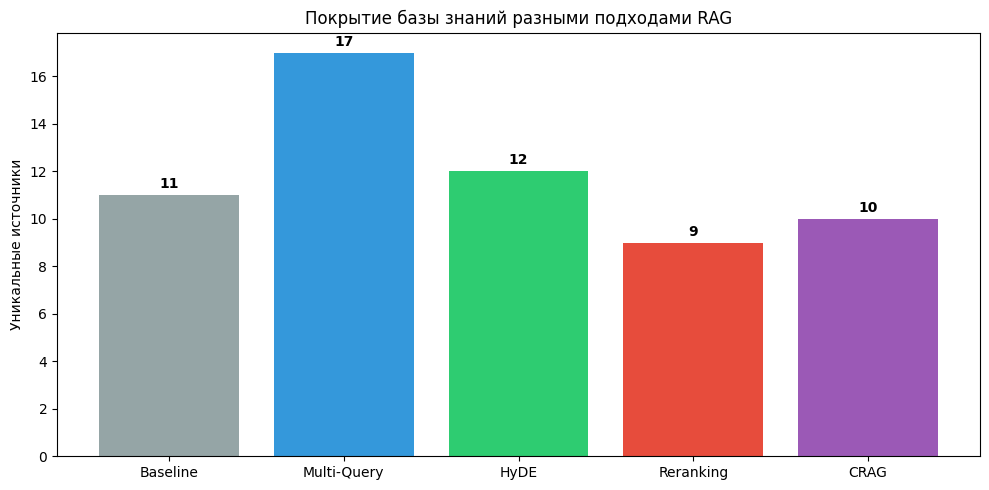

In [ ]:
import matplotlib.pyplot as plt

# Сравнение ответов
print('=' * 70)
print('СРАВНЕНИЕ ПОДХОДОВ')
print('=' * 70)

for q in test_questions:
    print(f'\n{"=" * 70}')
    print(f'❓ {q}')
    print(f'{"=" * 70}')

    approaches = {
        'Baseline': baseline_results[q]['answer'],
        'Multi-Query': mq_results[q]['answer'],
        'HyDE': hyde_results[q]['answer'],
        'Reranking': rerank_results[q]['answer'],
        'CRAG': crag_results[q]['answer'],
    }

    for name, answer in approaches.items():
        print(f'\n🏷️ {name}:')
        print(f'   {answer[:150]}...')

# Статистика: уникальные источники
print('\n\n' + '=' * 70)
print('📊 УНИКАЛЬНЫЕ ИСТОЧНИКИ ПО ПОДХОДАМ')
print('=' * 70)

approach_names = ['Baseline', 'Multi-Query', 'HyDE', 'Reranking', 'CRAG']
all_results = [baseline_results, mq_results, hyde_results, rerank_results, crag_results]
source_counts = []

for name, res in zip(approach_names, all_results):
    all_sources = set()
    for q in test_questions:
        all_sources.update(res[q]['sources'])
    source_counts.append(len(all_sources))
    print(f'  {name:<15}: {len(all_sources)} уникальных источников')

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax.bar(approach_names, source_counts, color=colors)
ax.set_ylabel('Уникальные источники')
ax.set_title('Покрытие базы знаний разными подходами RAG')
for bar, count in zip(bars, source_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Итоги

### Что мы изучили:

| Техника | Решает проблему | Когда использовать |
|---------|----------------|--------------------|
| **Baseline** | — | Простые запросы, прототипы |
| **Multi-Query** | Vocabulary mismatch | Неоднозначные запросы с множеством аспектов |
| **HyDE** | Вопрос ≠ документ | Техническая документация, когда вопрос далёк от ответа |
| **Reranking** | Неточный ranking | Когда точность top-3 критична |
| **CRAG** | Нерелевантные результаты | Production системы с гарантией качества |

### Trade-offs:

| Техника | Latency | API calls | Качество |
|---------|---------|-----------|----------|
| Baseline | ⚡ Быстро | 1 | ⭐⭐ |
| Multi-Query | 🐢 Средне | 2 | ⭐⭐⭐ |
| HyDE | 🐢 Средне | 2 | ⭐⭐⭐ |
| Reranking | ⚡ Быстро | 1 (cross-encoder локальный) | ⭐⭐⭐⭐ |
| CRAG | 🐌 Медленно | 5-15 (grading каждого doc) | ⭐⭐⭐⭐⭐ |

### Java аналогии (итог):

```java
// Baseline  = простой SELECT
// Multi-Query = UNION нескольких SELECT
// HyDE       = Query by Example
// Reranking  = двухфазный поиск (index scan → re-score)
// CRAG       = @Retryable + quality gate
```

### Следующие шаги:
- **Agentic RAG** — агент сам решает когда и как искать (Tool Calling + RAG)
- **Adaptive RAG** — выбор стратегии в зависимости от типа вопроса
- **Self-RAG** — генерация + самооценка + регенерация
- **Graph RAG** — знания как граф (Neo4j), а не текст